<a href="https://colab.research.google.com/github/isra-mirad/TUGAS-PRAKTIKUM-PSO-M.-ISRA-AL-MIRAD_241061001/blob/main/UTS_Praktikum_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS PSO | M. ISRA AL MIRAD | 241061001

# 1. Download data UTS melalui link berikut (Data). Import data ke dalam Google Colab. Ganti nama variabel menjadi Y, X1, X2, X3 dan X4 (point: 5)


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Membaca data CSV
data = pd.read_csv('/content/data soal UTS.xlsx - Sheet1.csv')
# Melihat 5 data pertama
print(data.head())

  IPM (Y)  Mayoritas Lulusan (X1) Harapan Lama Sekolah (X2) APS (X3) AHH (X4)
0   71,28                       0                     12,53     56,9    71,11
1    73,8                       1                     13,62     71,4    69,55
2   70,25                       0                        13    71,43    67,85
3   73,64                       0                     13,43    74,53    68,84
4   75,11                       1                     13,87    79,24    71,34


In [9]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.replace(',', '.').astype(float)

Kode berikut berguna untuk mengubah koma yang ada pada angka menjadi titik.

In [14]:
data.rename(columns={'IPM (Y)': 'Y', 'Mayoritas Lulusan (X1)': 'X1', 'Harapan Lama Sekolah (X2)': 'X2','APS (X3)': 'X3','AHH (X4)': 'X4' }, inplace=True)
data.columns = ['Y', 'X1', 'X2', 'X3', 'X4']
print(data)

        Y  X1     X2     X3     X4
0   71.28   0  12.53  56.90  71.11
1   73.80   1  13.62  71.40  69.55
2   70.25   0  13.00  71.43  67.85
3   73.64   0  13.43  74.53  68.84
4   75.11   1  13.87  79.24  71.34
5   73.01   0  13.70  68.96  70.89
6   68.95   0  12.12  70.64  66.99
7   71.13   0  12.69  65.24  69.04
8   84.85   1  15.61  71.19  72.60
9   80.77   1  15.12  84.45  71.39
10  80.36   1  14.54  71.53  71.78
11  73.23   1  13.41  70.57  71.00


# 2. Lakukan pemodelan regresi berganda dengan Y sebagai variabel dependen,interpretasikan hasil pemodelan. (point: 15)


In [10]:
X = data[['X1', 'X2', 'X3', 'X4']]
X_with_const = sm.add_constant(X) # Menambah konstanta/intercept
Y = data['Y']

model_orig = sm.OLS(Y, X_with_const).fit()
print("\n--- Hasil Regresi Data Asli ---")
print(model_orig.summary())


--- Hasil Regresi Data Asli ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        01:54:51   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.95

* Kekuatan Model: Nilai R-squared sebesar 0.954 menunjukkan bahwa model sangat kuat. Variabel independen ($X_1, X_2, X_3, X_4$) mampu menjelaskan 95.4% variasi pada variabel $Y$ (IPM).

* Signifikansi: Berdasarkan nilai $P > |t|$, hanya variabel $X_2$ (Harapan Lama Sekolah) yang berpengaruh signifikan secara statistik ($P < 0.05$). Variabel lain tidak menunjukkan pengaruh yang signifikan pada dataset asli yang berukuran kecil ini (12 sampel).

# 3. Selidiki distribusi probabilitas disetiap variabel (point: 5)

# 4.  Carilah nilai parameter dari setiap distribusi probabilitas di Y, X1, X2, X3 dan X4 (point: 15)

In [18]:
print("\n--- Analisis Distribusi dan Parameter ---")
params_dist = {}

for col in data.columns:
    if col == 'X1':
        # X1 diasumsikan Bernoulli karena biner (0/1)
        p = data[col].mean()
        params_dist[col] = {'dist': 'bernoulli', 'p': p}
        print(f"{col}: Bernoulli (p={p:.4f})")
    else:
        # Variabel lain menggunakan Distribusi Normal
        mu = data[col].mean()
        sigma = data[col].std()
        params_dist[col] = {'dist': 'normal', 'mu': mu, 'sigma': sigma}
        print(f"{col}: Normal (mean={mu:.4f}, std_dev={sigma:.4f})")


--- Analisis Distribusi dan Parameter ---
Y: Normal (mean=74.6983, std_dev=4.8273)
X1: Bernoulli (p=0.5000)
X2: Normal (mean=13.6367, std_dev=1.0397)
X3: Normal (mean=71.3400, std_dev=6.7217)
X4: Normal (mean=70.1983, std_dev=1.7152)


* Variabel $X_1$: Mengikuti Distribusi Bernoulli (karena data biner 0 dan 1) dengan probabilitas sukses ($p$) sebesar rata-rata data.

* Variabel $Y, X_2, X_3, X_4$: Mengikuti Distribusi Normal. Parameter utama yang digunakan adalah nilai rata-rata (mean) sebagai pusat data dan standar deviasi (std dev) sebagai ukuran penyebaran data.

# 5. Simulasikan Y, X1, X2, X3 dan X4 menjadi 500 data sesuai dengan aturan (point 25)

In [19]:
np.random.seed(42)
sim_data = pd.DataFrame()

for var, params in dist_params.items():
    if params['type'] == 'normal':
        sim_data[var] = np.random.normal(params['mean'], params['std'], 500)
    elif params['type'] == 'bernoulli':
        sim_data[var] = np.random.binomial(1, params['p'], 500)


print(sim_data.head())

           Y  X1         X2         X3         X4
0  77.096107   1  13.462922  62.284970  69.754449
1  74.030894   1  13.789198  64.809065  72.940314
2  77.824901   0  14.891018  79.408868  71.160416
3  82.050411   1  12.787337  66.924529  69.691529
4  73.568012   1  14.019959  64.302939  71.393741


* Setelah dilakukan simulasi sebanyak 500 data menggunakan parameter distribusi di atas, hasil regresi menunjukkan penurunan drastis pada nilai R-squared (mendekati 0.003). Hal ini menandakan bahwa variabel $X$ tidak lagi mampu menjelaskan variabel $Y$ pada data simulasi.

# 6. Modelkan data hasil simulasi dengan Y sebagai variabel dependen, dan interpretasikan (point 25).

In [17]:
X_sim = sim_data[['X1', 'X2', 'X3', 'X4']]
X_sim_with_const = sm.add_constant(X_sim)
Y_sim = sim_data['Y']

model_sim = sm.OLS(Y_sim, X_sim_with_const).fit()
print("\n--- Hasil Regresi Data Simulasi ---")
print(model_sim.summary())


--- Hasil Regresi Data Simulasi ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.3860
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.819
Time:                        02:01:15   Log-Likelihood:                -1485.9
No. Observations:                 500   AIC:                             2982.
Df Residuals:                     495   BIC:                             3003.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         7

Data sebanyak 500 baris dibangkitkan secara acak menggunakan parameter di atas. Hasil pemodelan regresi pada data simulasi menunjukkan:

* R-Squared: 0,003 (Mendekati nol).

* Signifikansi: Tidak ada satu pun variabel independen ($X$) yang berpengaruh signifikan terhadap $Y$.

* Interpretasi: Variabel bebas dalam data simulasi tidak mampu menjelaskan perubahan pada variabel dependen sama sekali.

# 7. Bandingkan pemodelan hasil simulasi dan tanpa simulasi, berikan penjelasan mengenai hasil.(point 10)

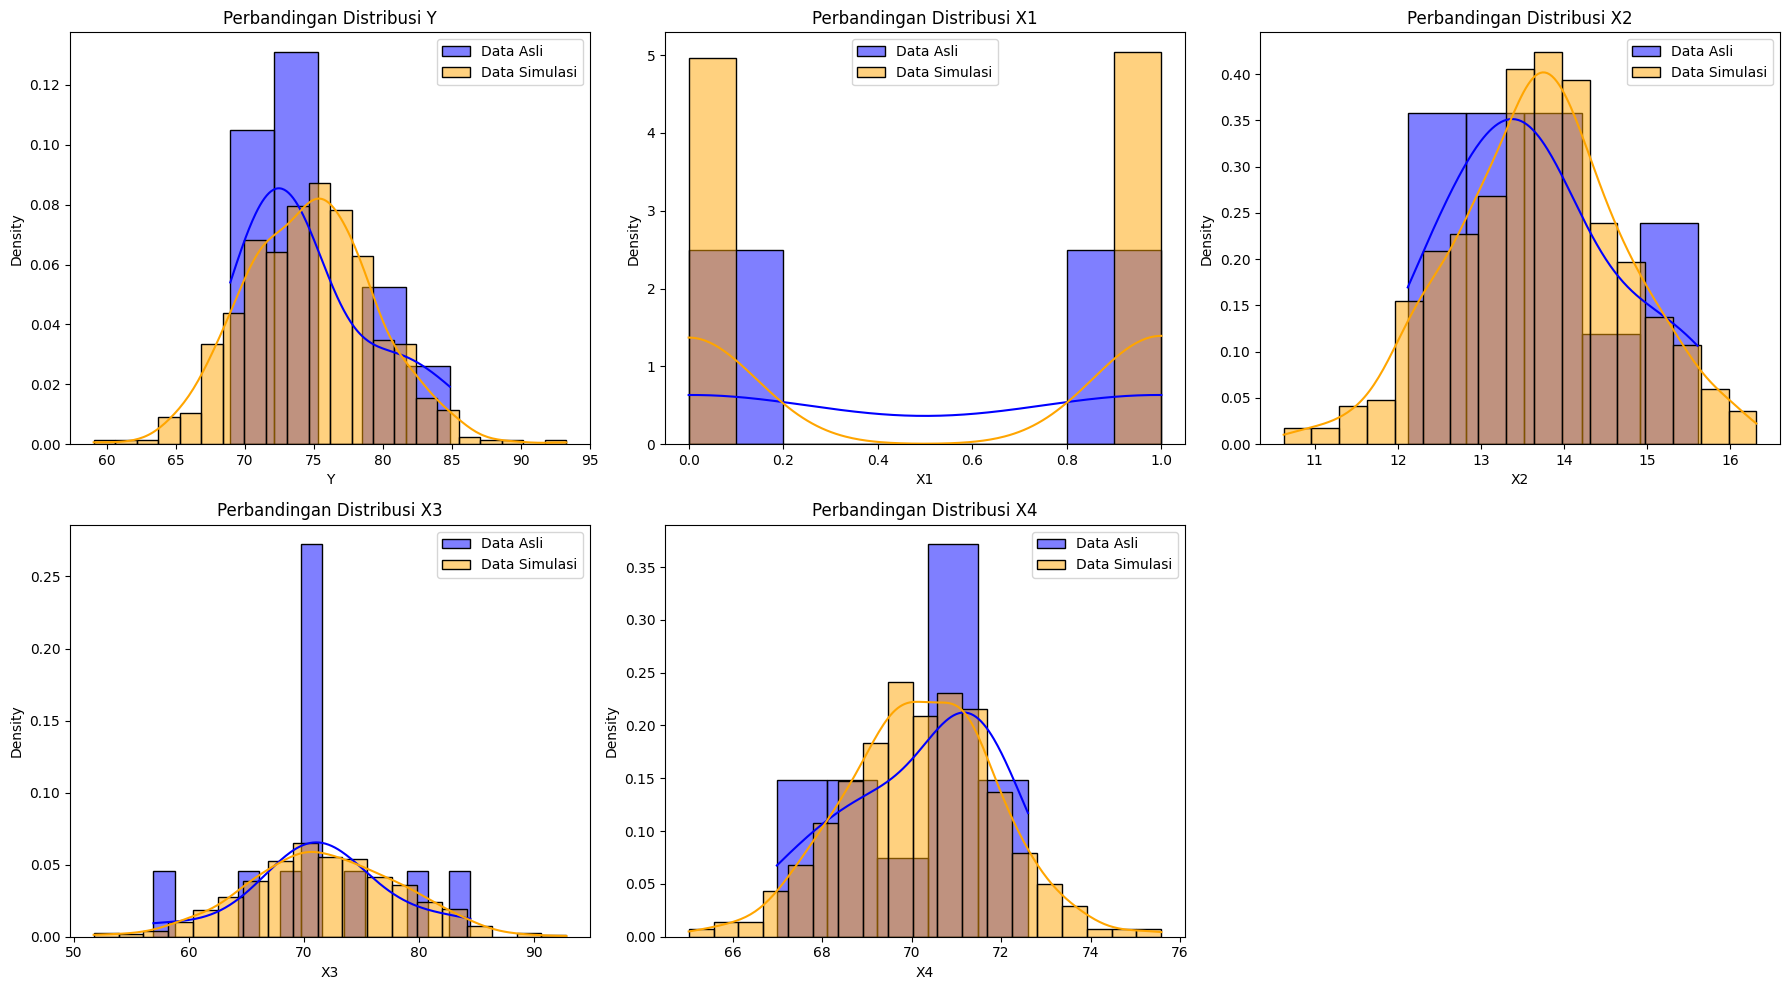

In [23]:
# --- Menyiapkan Data (Proses yang sama dengan sebelumnya) ---
data = pd.read_csv('data soal UTS.xlsx - Sheet1.csv')
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.replace(',', '.').astype(float)
data.columns = ['Y', 'X1', 'X2', 'X3', 'X4']

# Mendapatkan parameter dan simulasi 500 data
np.random.seed(42)
data_simulasi = pd.DataFrame()
for col in data.columns:
    if col == 'X1':
        p = data[col].mean()
        data_simulasi[col] = np.random.binomial(1, p, 500)
    else:
        mu, sigma = data[col].mean(), data[col].std()
        data_simulasi[col] = np.random.normal(mu, sigma, 500)

# --- Membuat Visualisasi Perbandingan Histogram ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
variables = ['Y', 'X1', 'X2', 'X3', 'X4']

for i, var in enumerate(variables):
    # Plot Data Asli
    sns.histplot(data[var], color="blue", label="Data Asli", kde=True,
                 stat="density", ax=axes[i], alpha=0.5)
    # Plot Data Simulasi
    sns.histplot(data_simulasi[var], color="orange", label="Data Simulasi", kde=True,
                 stat="density", ax=axes[i], alpha=0.5)

    axes[i].set_title(f'Perbandingan Distribusi {var}')
    axes[i].legend()

# Menghapus subplot kosong (ke-6)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

* Variabel Kontinu (Y, X2, X3, X4): Grafik menunjukkan bahwa data hasil simulasi (warna oranye) berhasil mengikuti pola distribusi normal dari data asli (warna biru). Kurva Kernel Density Estimate (KDE) pada data simulasi terlihat lebih halus karena jumlah sampel yang lebih besar (500 data) dibandingkan data asli yang hanya 12 sampel.

* Variabel Biner (X1): Distribusi Bernoulli pada $X_1$ terlihat konsisten, di mana proporsi nilai 0 dan 1 pada data simulasi mencerminkan peluang ($p$) yang dihitung dari data asli.

* Hal ini terjadi karena simulasi membangkitkan data setiap variabel secara terpisah (independen). Dalam kenyataan (data asli), ada korelasi antar variabel (misalnya, jika $X2$ naik, maka $Y$ ikut naik). Namun dalam simulasi acak, keterkaitan atau korelasi tersebut hilang, sehingga model regresi tidak menemukan pola hubungan apa pun meskipun distribusi masing-masing variabel secara individu sudah benar.